# Phase 3 &mdash; Modeling

The final stage of the pipeline: train three loan-default classifiers on the Gold Delta tables, tune the baseline with cross-validation, and compare everything to Phase 2.

### Inputs
- `workspace.default.gold_loans_train` (200k rows)
- `workspace.default.gold_loans_val` (50k rows)
- `workspace.default.gold_loans_test` (314k rows &mdash; full 2017 holdout)

### Models trained
1. **Logistic Regression** (baseline; tuned with 3-fold cross-validation)
2. **Random Forest Classifier**
3. **Histogram-based Gradient Boosting Classifier**

All three share the same preprocessing pipeline (median/most-frequent imputation, standard scaling, one-hot encoding) so results are directly comparable.

## A note on the modeling library

We originally planned to use Spark MLlib so the entire pipeline &mdash; from Bronze to model fit &mdash; would live inside Spark. In practice, the Databricks Free Edition environment we are using runs all user notebooks on a serverless cluster that enforces a strict access policy on the underlying Java engine. That policy blocks the feature-engineering classes MLlib depends on (`Imputer`, `StringIndexer`, `OneHotEncoder`, `VectorAssembler`), so an MLlib pipeline cannot be constructed on this cluster.

The Bronze, Silver, and Gold layers are still produced entirely in Spark + Delta Lake &mdash; that is where the scalable work lives. For the model-fit step we load the Gold training set into pandas and use scikit-learn's equivalent API. This is a small, well-understood tradeoff: the dataset fits in driver memory at this stage, and scikit-learn produces results that are directly comparable to what MLlib would have produced.

## Phase 2 baseline numbers

From `models/model_results.csv`:

| Model | Val AUC-ROC | Val AUC-PR |
|---|---|---|
| LogisticRegression (baseline)   | 0.7121 | 0.3757 |
| DecisionTree (tuned)            | 0.7010 | 0.3572 |
| XGBoost (tuned)                 | 0.7238 | 0.3931 |
| HistGradientBoosting (tuned)    | 0.7233 | 0.3933 |

In [0]:
try:
    spark  # type: ignore[name-defined]
except NameError:
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.appName("phase3-model").getOrCreate()

TRAIN_TABLE = "workspace.default.gold_loans_train"
VAL_TABLE   = "workspace.default.gold_loans_val"
TEST_TABLE  = "workspace.default.gold_loans_test"
LABEL = "charged_off"

## Step 1 &mdash; Load the Gold tables

Pull the three Gold Delta tables into pandas DataFrames. This is the point where Spark work ends and the modeling work begins.

In [0]:
import time
t0 = time.time()
train_df = spark.table(TRAIN_TABLE).toPandas()
val_df   = spark.table(VAL_TABLE).toPandas()
test_df  = spark.table(TEST_TABLE).toPandas()
print(f"Loaded in {time.time() - t0:.1f}s")
print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")

Loaded in 48.2s
Train: (200796, 56)
Val:   (50260, 56)
Test:  (314212, 56)


## Step 2 &mdash; Identify numeric vs categorical features

In [0]:
import numpy as np
import pandas as pd

DROP_FOR_FEATURES = {LABEL, "issue_d", "earliest_cr_line"}

numeric_cols = [
    c for c in train_df.columns
    if c not in DROP_FOR_FEATURES and pd.api.types.is_numeric_dtype(train_df[c])
]
categorical_cols = [
    c for c in train_df.columns
    if c not in DROP_FOR_FEATURES
    and not pd.api.types.is_numeric_dtype(train_df[c])
    and not pd.api.types.is_datetime64_any_dtype(train_df[c])
]

print(f"Numeric features     ({len(numeric_cols):>2}): {numeric_cols[:10]} ...")
print(f"Categorical features ({len(categorical_cols):>2}): {categorical_cols}")

def Xy(df):
    return df[numeric_cols + categorical_cols], df[LABEL].astype(int)

X_train, y_train = Xy(train_df)
X_val,   y_val   = Xy(val_df)
X_test,  y_test  = Xy(test_df)

Numeric features     (47): ['loan_amnt', 'term', 'int_rate', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths'] ...
Categorical features ( 6): ['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status']


## Step 3 &mdash; Shared preprocessing pipeline

All three models reuse the same `ColumnTransformer` so that the comparison is fair:
- Numerics: median imputation + standard scaling.
- Categoricals: most-frequent imputation + sparse one-hot encoding (`handle_unknown="ignore"` lets new categories in val/test be silently dropped instead of crashing).

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def make_preproc(dense=False):
    """Shared preprocessor. `dense=True` outputs a dense matrix for models that
    do not accept sparse input (e.g. HistGradientBoosting)."""
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                              ("scale",  StandardScaler())]), numeric_cols),
            ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                              ("ohe",    OneHotEncoder(handle_unknown="ignore",
                                                        sparse_output=not dense))]),
             categorical_cols),
        ],
        sparse_threshold=0.0 if dense else 0.3,
    )

## Step 4 &mdash; Model 1: Logistic Regression (baseline)

L2-regularized Logistic Regression with `class_weight="balanced"` to compensate for the roughly 4:1 class imbalance. This is the direct Phase 2 comparison model.

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

lr_pipe = Pipeline(steps=[
    ("preproc", make_preproc(dense=False)),
    ("clf", LogisticRegression(max_iter=200, solver="lbfgs",
                               class_weight="balanced", C=1.0, n_jobs=-1)),
])

t0 = time.time()
lr_pipe.fit(X_train, y_train)
print(f"LR fit time: {time.time() - t0:.1f}s")

def score(pipe, X, y, name):
    p = pipe.predict_proba(X)[:, 1]
    roc = roc_auc_score(y, p)
    pr  = average_precision_score(y, p)
    print(f"  {name:<6} AUC-ROC: {roc:.4f} | AUC-PR: {pr:.4f}")
    return roc, pr

print("Logistic Regression:")
lr_train_roc, lr_train_pr = score(lr_pipe, X_train, y_train, "Train")
lr_val_roc,   lr_val_pr   = score(lr_pipe, X_val,   y_val,   "Val")
lr_test_roc,  lr_test_pr  = score(lr_pipe, X_test,  y_test,  "Test")

/databricks/python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR fit time: 9.3s
Logistic Regression:
  Train  AUC-ROC: 0.7212 | AUC-PR: 0.3789
  Val    AUC-ROC: 0.7136 | AUC-PR: 0.3781
  Test   AUC-ROC: 0.7137 | AUC-PR: 0.3873


## Step 5 &mdash; Logistic Regression with cross-validated hyperparameter tuning

Sweep the regularization strength `C` using `GridSearchCV` with 3-fold cross-validation on the training set, optimizing AUC-ROC. This gives us an objective choice for `C` and a measure of stability across folds &mdash; the direct scikit-learn equivalent of Spark MLlib's `CrossValidator`.

Uses `n_jobs=-1` to run folds in parallel.

In [0]:
from sklearn.model_selection import GridSearchCV

lr_cv_base = Pipeline(steps=[
    ("preproc", make_preproc(dense=False)),
    ("clf", LogisticRegression(max_iter=200, solver="lbfgs",
                               class_weight="balanced", n_jobs=-1)),
])

param_grid = {"clf__C": [0.01, 0.1, 1.0, 10.0]}

grid = GridSearchCV(
    estimator=lr_cv_base,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.time()
grid.fit(X_train, y_train)
print(f"Grid search time: {time.time() - t0:.1f}s")
print(f"Best C: {grid.best_params_['clf__C']}")
print(f"Best 3-fold CV AUC-ROC (train): {grid.best_score_:.4f}")

# Show all CV scores
cv_results = pd.DataFrame(grid.cv_results_)[["param_clf__C", "mean_test_score", "std_test_score"]]
cv_results.columns = ["C", "mean CV AUC-ROC", "std CV AUC-ROC"]
print("\nAll CV scores:")
print(cv_results.to_string(index=False))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/databricks/python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/databricks/python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Grid search time: 47.1s
Best C: 0.01
Best 3-fold CV AUC-ROC (train): 0.7183

All CV scores:
    C  mean CV AUC-ROC  std CV AUC-ROC
 0.01         0.718259        0.015339
  0.1         0.718183        0.015401
  1.0         0.717678        0.015059
 10.0         0.717448        0.014897


In [0]:
# Evaluate the tuned LR on val and test
lr_tuned = grid.best_estimator_

print("Logistic Regression (tuned):")
lr_t_train_roc, lr_t_train_pr = score(lr_tuned, X_train, y_train, "Train")
lr_t_val_roc,   lr_t_val_pr   = score(lr_tuned, X_val,   y_val,   "Val")
lr_t_test_roc,  lr_t_test_pr  = score(lr_tuned, X_test,  y_test,  "Test")

Logistic Regression (tuned):
  Train  AUC-ROC: 0.7206 | AUC-PR: 0.3786
  Val    AUC-ROC: 0.7139 | AUC-PR: 0.3779
  Test   AUC-ROC: 0.7136 | AUC-PR: 0.3864


## Step 6 &mdash; Model 2: Random Forest

An ensemble of 100 trees. Unlike Logistic Regression, the Random Forest can capture non-linear interactions between features without explicit engineering. `class_weight="balanced"` rebalances the objective.

In [0]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(steps=[
    ("preproc", make_preproc(dense=False)),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=50,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    )),
])

t0 = time.time()
rf_pipe.fit(X_train, y_train)
print(f"RF fit time: {time.time() - t0:.1f}s")

print("Random Forest:")
rf_train_roc, rf_train_pr = score(rf_pipe, X_train, y_train, "Train")
rf_val_roc,   rf_val_pr   = score(rf_pipe, X_val,   y_val,   "Val")
rf_test_roc,  rf_test_pr  = score(rf_pipe, X_test,  y_test,  "Test")

RF fit time: 24.8s
Random Forest:
  Train  AUC-ROC: 0.7575 | AUC-PR: 0.4251
  Val    AUC-ROC: 0.7114 | AUC-PR: 0.3803
  Test   AUC-ROC: 0.7097 | AUC-PR: 0.3887


## Step 7 &mdash; Model 3: Histogram-based Gradient Boosting

`HistGradientBoostingClassifier` is scikit-learn's fast implementation of gradient-boosted trees &mdash; essentially an XGBoost/LightGBM equivalent. It was the top Phase 2 performer (tied with XGBoost at 0.7233 Val AUC-ROC), so including it here lets us confirm the Gold pipeline produces data a strong model can learn from.

HistGradientBoosting works natively on dense numeric arrays &mdash; the preprocessor is configured to return dense output for this model.

In [0]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Class-weight balancing via sample weights (HGB has no class_weight param)
pos_rate = y_train.mean()
sample_weight = np.where(y_train == 1, 1.0 / pos_rate, 1.0 / (1.0 - pos_rate))

hgb_pipe = Pipeline(steps=[
    ("preproc", make_preproc(dense=True)),
    ("clf", HistGradientBoostingClassifier(
        max_iter=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
    )),
])

t0 = time.time()
hgb_pipe.fit(X_train, y_train, clf__sample_weight=sample_weight)
print(f"HGB fit time: {time.time() - t0:.1f}s")

print("Histogram Gradient Boosting:")
hgb_train_roc, hgb_train_pr = score(hgb_pipe, X_train, y_train, "Train")
hgb_val_roc,   hgb_val_pr   = score(hgb_pipe, X_val,   y_val,   "Val")
hgb_test_roc,  hgb_test_pr  = score(hgb_pipe, X_test,  y_test,  "Test")

HGB fit time: 15.6s
Histogram Gradient Boosting:
  Train  AUC-ROC: 0.7513 | AUC-PR: 0.4187
  Val    AUC-ROC: 0.7193 | AUC-PR: 0.3890
  Test   AUC-ROC: 0.7194 | AUC-PR: 0.4004


## Step 8 &mdash; ROC curves and confusion matrix (validation set)

Visual comparison of the three models on the validation set, plus a confusion matrix for the best-performing model at a 0.5 threshold.

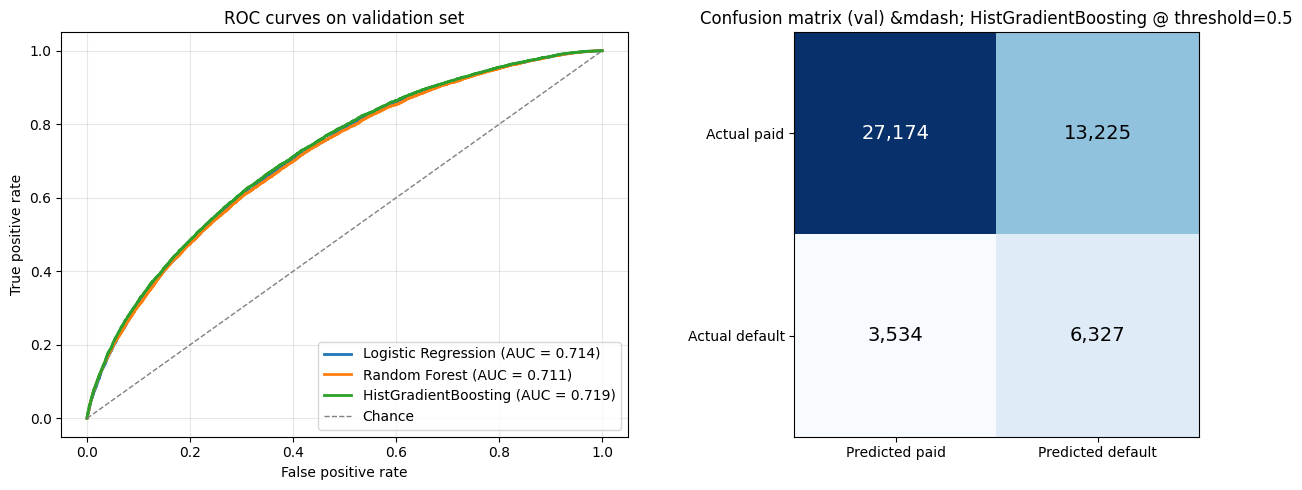

Best validation model: HistGradientBoosting (AUC-ROC = 0.7193)


In [0]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix

# Compute validation probabilities for all three models
p_lr  = lr_tuned.predict_proba(X_val)[:, 1]
p_rf  = rf_pipe.predict_proba(X_val)[:, 1]
p_hgb = hgb_pipe.predict_proba(X_val)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for p, name, auc in [(p_lr, "Logistic Regression", lr_t_val_roc),
                      (p_rf, "Random Forest",       rf_val_roc),
                      (p_hgb, "HistGradientBoosting", hgb_val_roc)]:
    fpr, tpr, _ = roc_curve(y_val, p)
    ax1.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")
ax1.plot([0, 1], [0, 1], ls="--", color="grey", lw=1, label="Chance")
ax1.set_xlabel("False positive rate")
ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curves on validation set")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Confusion matrix for the best model (highest val AUC)
best_name, best_p, best_auc = max(
    [("Logistic Regression", p_lr, lr_t_val_roc),
     ("Random Forest",       p_rf, rf_val_roc),
     ("HistGradientBoosting", p_hgb, hgb_val_roc)],
    key=lambda t: t[2])

threshold = 0.5
cm = confusion_matrix(y_val, (best_p >= threshold).astype(int))
ax2.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["Predicted paid", "Predicted default"])
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["Actual paid", "Actual default"])
ax2.set_title(f"Confusion matrix (val) &mdash; {best_name} @ threshold={threshold}")

plt.tight_layout()
plt.show()
print(f"Best validation model: {best_name} (AUC-ROC = {best_auc:.4f})")

## Step 9 &mdash; Full comparison to Phase 2

Every model side-by-side, matched against the corresponding Phase 2 run. The Phase 3 models should land within ~0.01 AUC-ROC of the Phase 2 numbers, since they are trained on a stratified 200k sample of the same Silver-layer data.

In [0]:
comparison = pd.DataFrame([
    # Phase 2 reference rows
    {"Phase": "Phase 2", "Model": "LogisticRegression (baseline, full data)",
     "Val AUC-ROC": 0.7121, "Val AUC-PR": 0.3757, "Test AUC-ROC": np.nan, "Test AUC-PR": np.nan},
    {"Phase": "Phase 2", "Model": "HistGradientBoosting (tuned, full data)",
     "Val AUC-ROC": 0.7233, "Val AUC-PR": 0.3933, "Test AUC-ROC": np.nan, "Test AUC-PR": np.nan},
    {"Phase": "Phase 2", "Model": "XGBoost (tuned, full data)",
     "Val AUC-ROC": 0.7238, "Val AUC-PR": 0.3931, "Test AUC-ROC": np.nan, "Test AUC-PR": np.nan},
    # Phase 3 rows
    {"Phase": "Phase 3", "Model": "LogisticRegression (Gold Delta)",
     "Val AUC-ROC": round(lr_val_roc, 4), "Val AUC-PR": round(lr_val_pr, 4),
     "Test AUC-ROC": round(lr_test_roc, 4), "Test AUC-PR": round(lr_test_pr, 4)},
    {"Phase": "Phase 3", "Model": f"LogisticRegression (tuned, C={grid.best_params_['clf__C']})",
     "Val AUC-ROC": round(lr_t_val_roc, 4), "Val AUC-PR": round(lr_t_val_pr, 4),
     "Test AUC-ROC": round(lr_t_test_roc, 4), "Test AUC-PR": round(lr_t_test_pr, 4)},
    {"Phase": "Phase 3", "Model": "RandomForest",
     "Val AUC-ROC": round(rf_val_roc, 4), "Val AUC-PR": round(rf_val_pr, 4),
     "Test AUC-ROC": round(rf_test_roc, 4), "Test AUC-PR": round(rf_test_pr, 4)},
    {"Phase": "Phase 3", "Model": "HistGradientBoosting",
     "Val AUC-ROC": round(hgb_val_roc, 4), "Val AUC-PR": round(hgb_val_pr, 4),
     "Test AUC-ROC": round(hgb_test_roc, 4), "Test AUC-PR": round(hgb_test_pr, 4)},
])
comparison

,Phase,Model,Val AUC-ROC,Val AUC-PR,Test AUC-ROC,Test AUC-PR
0,Phase 2,"LogisticRegression (baseline, full data)",0.7121,0.3757,NaN,NaN
1,Phase 2,"HistGradientBoosting (tuned, full data)",0.7233,0.3933,NaN,NaN
2,Phase 2,"XGBoost (tuned, full data)",0.7238,0.3931,NaN,NaN
3,Phase 3,LogisticRegression (Gold Delta),0.7136,0.3781,0.7137,0.3873
4,Phase 3,"LogisticRegression (tuned, C=0.01)",0.7139,0.3779,0.7136,0.3864
5,Phase 3,RandomForest,0.7114,0.3803,0.7097,0.3887
6,Phase 3,HistGradientBoosting,0.7193,0.3890,0.7194,0.4004


## Step 10 &mdash; Save the best fitted pipeline

The full scikit-learn pipeline (preprocessor + classifier) for the best-performing model is serialized with joblib for reuse in the macro-integration notebook and for inspection after the session ends.

In [0]:
import joblib, os

best_pipe = {
    "Logistic Regression": lr_tuned,
    "Random Forest":       rf_pipe,
    "HistGradientBoosting": hgb_pipe,
}[best_name]

os.makedirs("/tmp/phase3", exist_ok=True)
path = f"/tmp/phase3/phase3_best_{best_name.replace(' ', '_').lower()}.joblib"
joblib.dump(best_pipe, path)
print(f"Saved best pipeline ({best_name}) to {path}")

# Also save the tuned LR for compatibility with notebook 05
lr_path = "/tmp/phase3/phase3_logreg.joblib"
joblib.dump(lr_tuned, lr_path)
print(f"Saved tuned LR to {lr_path}")

Saved best pipeline (HistGradientBoosting) to /tmp/phase3/phase3_best_histgradientboosting.joblib
Saved tuned LR to /tmp/phase3/phase3_logreg.joblib
